# Modelo de Ising — Algoritmo de Metropolis-Hastings

Implementação da classe `IsingModel` com condições de fronteira periódicas,  
`J = 1`, `h = 0`, `kb = 1`, rede 2D quadrada de lado `L`, spins iniciais `+1`.

In [1]:
run_with_numba = True

if run_with_numba:
    import numba as np
else:
    import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import CubicSpline, RegularGridInterpolator

J  = 1
h  = 0
kb = 1
rnd = np.random.default_rng(seed=12938142948123)


# ── Classe do Modelo de Ising ────────────────────────────────────────────────
class IsingModel:

    def __init__(self, L, T):
        self.L = L
        self.T = T
        self.spins = np.ones((L, L))
        self.energies       = []
        self.magnetizations = []

    def calc_ener_spin(self, i, j) -> float:
        L     = self.L
        own   = self.spins[i, j]
        right = self.spins[i,          (j + 1) % L]
        down  = self.spins[(i + 1) % L,  j        ]
        return -J * own * (right + down) - h * own

    def calc_ener(self) -> float:
        right = np.roll(self.spins, -1, axis=1)
        down  = np.roll(self.spins, -1, axis=0)
        return -J * np.sum(self.spins * (right + down)) - h * np.sum(self.spins)

    def calc_mag(self) -> float:
        return J * np.sum(self.spins) / self.L**2

    def flip(self, i, j) -> None:
        self.spins[i, j] *= -1

    def iter_monte_carlo(self, n_iter):
        L = self.L
        self.energies       = np.empty(n_iter + 1)
        self.magnetizations = np.empty(n_iter + 1)

        E   = self.calc_ener()
        mag = self.calc_mag()
        self.energies[0]       = E
        self.magnetizations[0] = mag

        i_vals = rnd.integers(0, L,     size=n_iter)
        j_vals = rnd.integers(0, L,     size=n_iter)
        u_vals = rnd.uniform (0.0, 1.0, size=n_iter)

        for k in tqdm(range(n_iter), desc=f"L={L:6d}, T={self.T:8.4f}"):
            i, j, u = i_vals[k], j_vals[k], u_vals[k]
            own = self.spins[i, j]

            sumviz = (self.spins[i,          (j + 1) % L] +
                      self.spins[i,          (j - 1) % L] +
                      self.spins[(i + 1) % L,  j        ] +
                      self.spins[(i - 1) % L,  j        ])

            delta = 2.0 * own * (J * sumviz + h)

            if delta < 0 or np.exp(-delta / (kb * self.T)) > u:
                self.flip(i, j)
                E   += delta
                mag -= 2.0 * J * own / L**2

            self.energies[k + 1]       = E
            self.magnetizations[k + 1] = mag

    @property
    def energy(self):
        return np.array(self.energies)

    @property
    def magnetization(self):
        return np.array(self.magnetizations)


AttributeError: module 'numba' has no attribute 'random'

---
## Exercício 1 — Tempo de Termalização

### 1(a)

Para cada combinação de $L \in \{16, 32, 64, 128\}$ e $T \in \{1, 2, 3, 4\}$,
corre a simulação e representa a energia por spin $e \equiv E/L^2$
em função do número de iteração $N$.

O número de iterações é $n_\mathrm{iter} = n_\mathrm{sweeps} \cdot L^2$
para que o número de varrimentos seja idêntico em todos os tamanhos.

L=   128, T=  4.0000: 100%|██████████| 163840/163840 [00:01<00:00, 123925.74it/s]


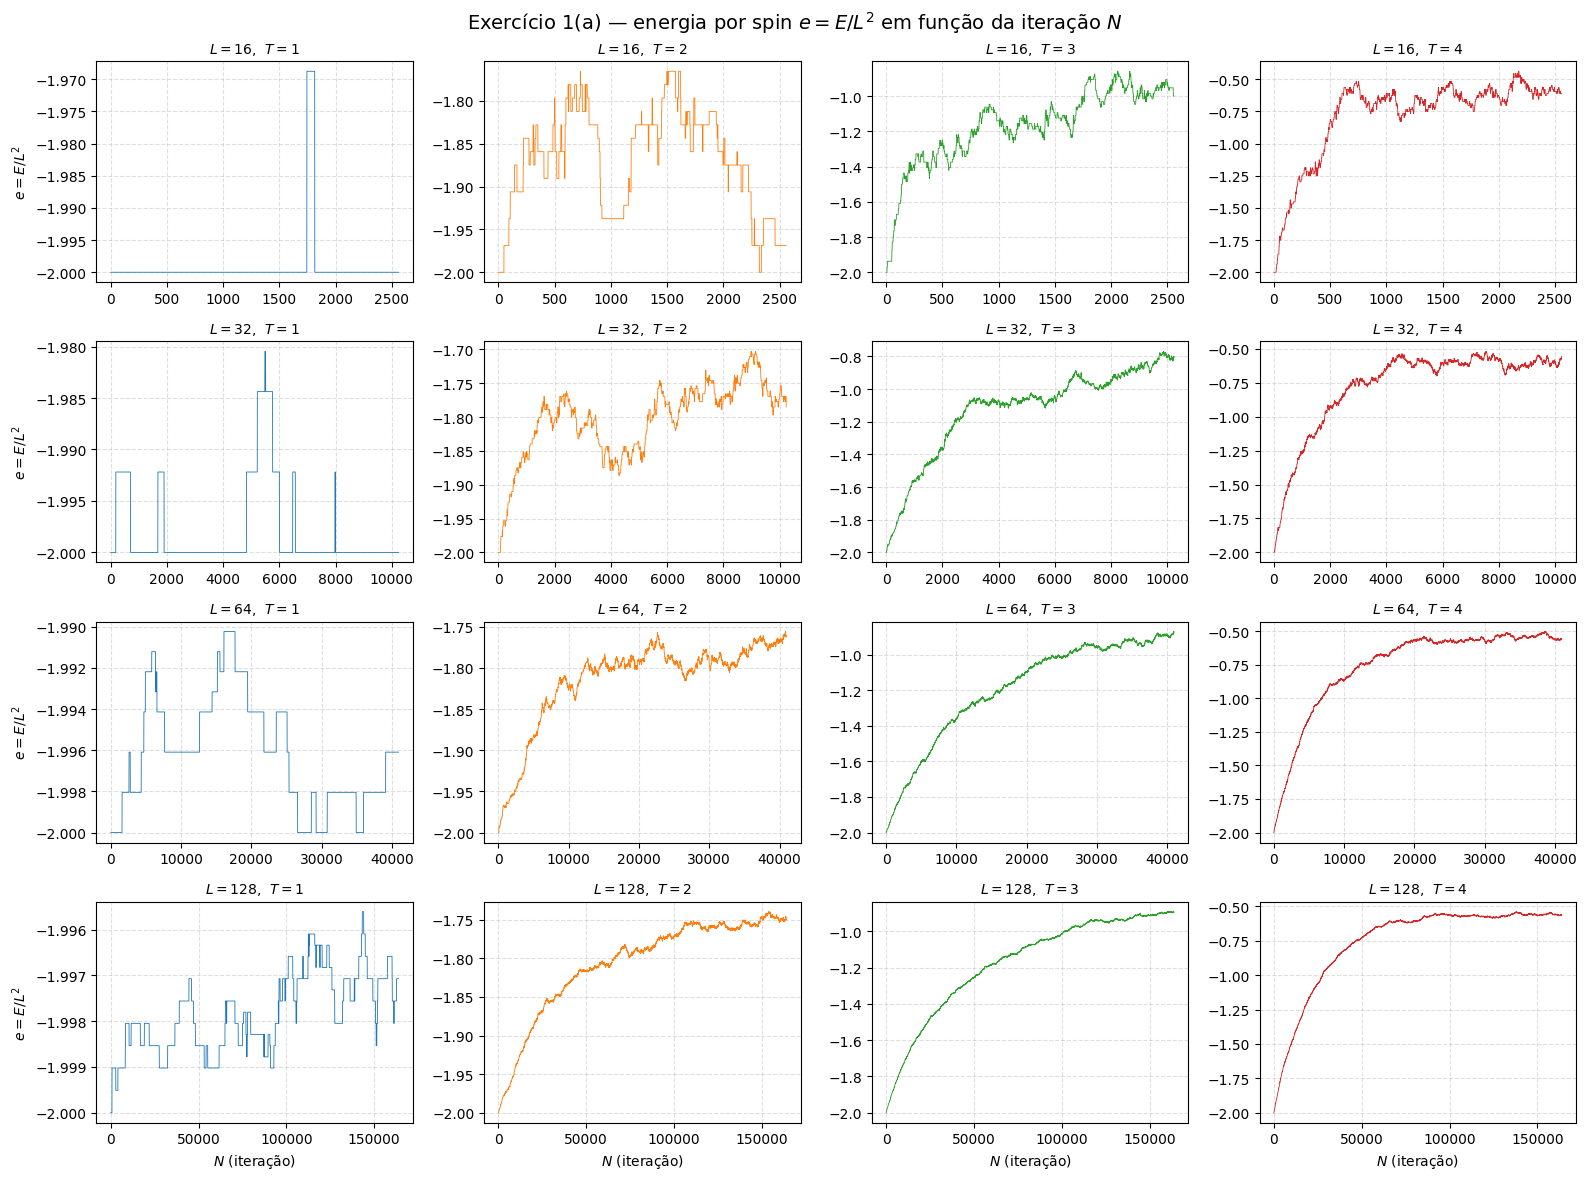

In [ ]:
L_values = [16, 32, 64, 128]
T_values = [1, 2, 3, 4]
n_sweeps = 10

results = {}

for L in L_values:
    n_iter = n_sweeps * L**2
    for T in T_values:
        model = IsingModel(L, T)
        model.iter_monte_carlo(n_iter)
        results[(L, T)] = model.energy / L**2

# ── Gráficos: grelha 4×4, linhas = L, colunas = T ────────────────────────────
fig, axes = plt.subplots(len(L_values), len(T_values), figsize=(16, 12), squeeze=False)
fig.suptitle(
    r"Exercício 1(a) — energia por spin $e = E/L^2$ em função da iteração $N$",
    fontsize=14
)
cores = ["C0", "C1", "C2", "C3"]

for row, L in enumerate(L_values):
    for col, T in enumerate(T_values):
        ax = axes[row, col]
        e  = results[(L, T)]
        N  = np.arange(len(e))
        ax.plot(N, e, lw=0.6, color=cores[col])
        ax.set_title(f"$L = {L}$,  $T = {T}$", fontsize=10)
        ax.grid(True, ls="--", alpha=0.4)
        if row == len(L_values) - 1:
            ax.set_xlabel("$N$ (iteração)")
        if col == 0:
            ax.set_ylabel(r"$e = E/L^2$")

plt.tight_layout()
plt.show()


### 1(b)

Fit da energia por spin à função de termalização:

$$e(N) = e_f + (e_0 - e_f)\,e^{-N/\tau_\mathrm{term}}$$

com $e_0 = -2$ fixo (estado inicial). O fit determina $e_f(L,T)$ e $\tau_\mathrm{term}(L,T)$.

**Nota sobre a caso $T = 1$:**
A $T = 1$ (muito abaixo de $T_c \approx 2.27$), o estado inicial todo `+1` já é
praticamente o estado de equilíbrio: $e_0 \approx e_f \approx -2$. O termo
$(e_0 - e_f)$ é então $\approx 0$ e $\tau$ deixa de ser identificável pelos dados
— qualquer valor de $\tau$ produz a mesma curva. Nesta região, fisicamente,
$\tau_\mathrm{term} \to 0$ (o sistema não precisa de termalizar).

Para tornar este facto explícito, a tabela inclui:
- as colunas brutas $e_f$ e $\tau$ devolvidas pelo `curve_fit`;
- uma coluna `status` que marca como `unreliable` os fits em que (i) $e_f$ encosta no
  limite, (ii) $\sigma_\tau/\tau > 0.3$, ou (iii) $\tau > N_{\max}$;
- uma coluna $\tau_\mathrm{use}$ que é igual a $\tau$ para os fits ok e a $1$ para
  os fits degenerados/não fiáveis (valor sentinela; corresponde a $\tau \to 0$,
  saturado em 1 para evitar problemas numéricos posteriores).

É $\tau_\mathrm{use}$ que é usado no exercício 2 para definir $N_\mathrm{term}=4\tau_\mathrm{use}$.

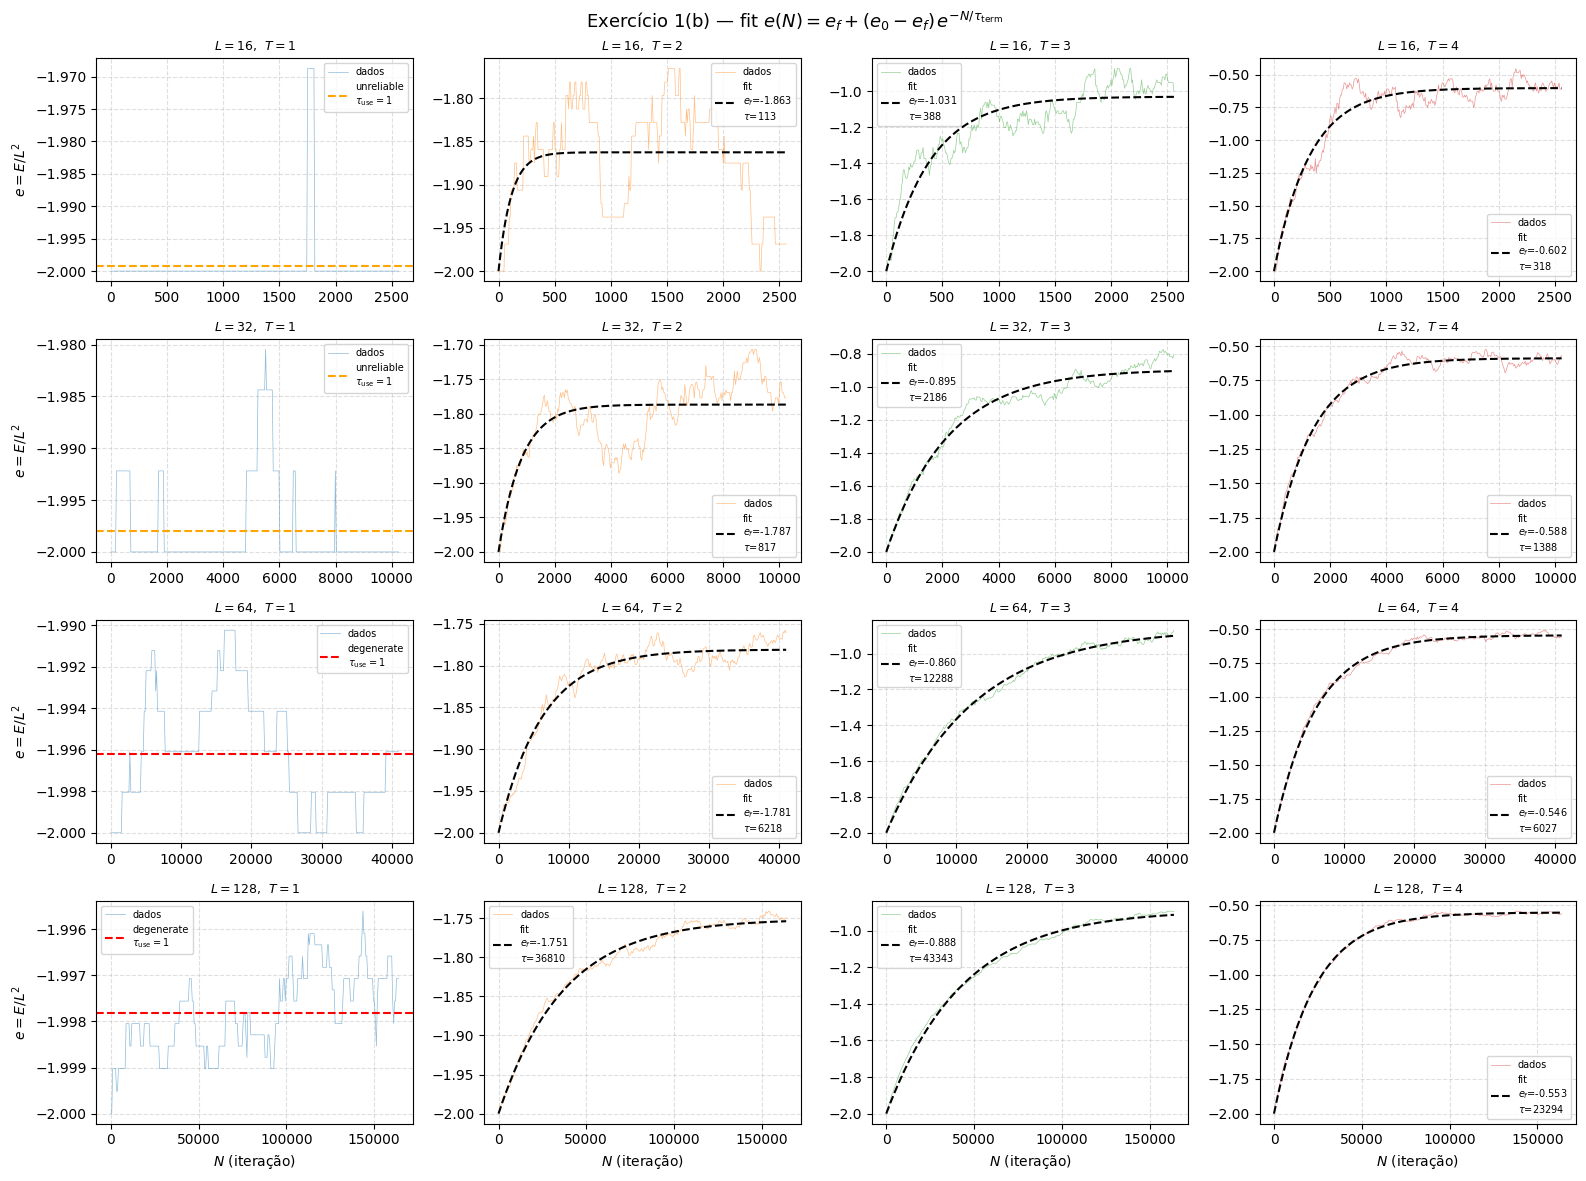


   L    T         ef      ±σ_ef       τ (raw)          ±σ_τ       status     τ_use
──────────────────────────────────────────────────────────────────────────────────────
  16    1    -1.9978     0.0031        2055.3        4518.2   unreliable       1.0
  16    2    -1.8625     0.0027         113.2          20.4           ok     113.2
  16    3    -1.0308     0.0064         388.2          11.6           ok     388.2
  16    4    -0.6021     0.0052         317.7           6.1           ok     317.7
  32    1    -1.9980     0.0002          55.4         144.7   unreliable       1.0
  32    2    -1.7869     0.0020         817.3          51.5           ok     817.3
  32    3    -0.8945     0.0047        2185.7          33.4           ok    2185.7
  32    4    -0.5877     0.0023        1388.2          11.1           ok    1388.2
  64    1    -1.9962     0.0027       (plana)             –   degenerate       1.0
  64    2    -1.7809     0.0008        6218.4         101.2           ok    6218.4

In [ ]:
def therm_model(N, ef, tau):
    e0 = -2.0
    return ef + (e0 - ef) * np.exp(-N / tau)

# Parâmetros das verificações de fiabilidade
RANGE_THRESHOLD       = 0.01
REL_UNCERTAINTY_LIMIT = 0.3
EF_BOUND_TOL          = 1e-3

fit_params = {}   # (L,T) -> [ef, tau]   (valores brutos do curve_fit)
fit_errors = {}   # (L,T) -> [σ_ef, σ_τ] (idem)
fit_status = {}   # (L,T) -> 'ok' | 'degenerate' | 'unreliable' | 'failed'
tau_use    = {}   # (L,T) -> valor de τ a usar no exercício 2

for L in L_values:
    for T in T_values:

        e = results[(L, T)]
        N = np.arange(len(e), dtype=float)

        step  = max(1, len(e) // 500)
        e_sub = e[::step]
        N_sub = N[::step]

        # ── Caso 1: curva essencialmente plana — fit não é possível ────────
        if (e_sub.max() - e_sub.min()) < RANGE_THRESHOLD:
            fit_params[(L, T)] = np.array([float(e_sub.mean()), np.nan])
            fit_errors[(L, T)] = np.array([float(e_sub.std()),  np.nan])
            fit_status[(L, T)] = 'degenerate'
            tau_use   [(L, T)] = 1.0
            continue

        # ── Caso 2: tentar o fit ───────────────────────────────────────────
        n_tail = max(1, len(e_sub) // 10)
        ef_p0  = float(e_sub[-n_tail:].mean())
        tau_p0 = float(L**2)

        try:
            popt, pcov = curve_fit(
                therm_model, N_sub, e_sub,
                p0     = [ef_p0, tau_p0],
                bounds = ([-2.5, 1.0], [0.5, np.inf]),
                maxfev = 10000,
            )
            perr = np.sqrt(np.diag(pcov))
        except (RuntimeError, ValueError):
            fit_params[(L, T)] = np.full(2, np.nan)
            fit_errors[(L, T)] = np.full(2, np.nan)
            fit_status[(L, T)] = 'failed'
            tau_use   [(L, T)] = 1.0
            continue

        # ── Caso 3: verificar fiabilidade do fit ───────────────────────────
        ef, tau         = popt
        sigma_ef, s_tau = perr
        N_max           = float(N_sub[-1])

        ef_at_bound      = (abs(ef - 0.5)  < EF_BOUND_TOL or
                            abs(ef + 2.5)  < EF_BOUND_TOL)
        huge_uncertainty = s_tau > abs(tau) * REL_UNCERTAINTY_LIMIT
        tau_unobservable = tau > N_max

        fit_params[(L, T)] = popt
        fit_errors[(L, T)] = perr

        if ef_at_bound or huge_uncertainty or tau_unobservable:
            fit_status[(L, T)] = 'unreliable'
            tau_use   [(L, T)] = 1.0
        else:
            fit_status[(L, T)] = 'ok'
            tau_use   [(L, T)] = float(tau)

# ── Gráficos: dados + fit ────────────────────────────────────────────────────
fig, axes = plt.subplots(len(L_values), len(T_values), figsize=(16, 12), squeeze=False)
fig.suptitle(
    r"Exercício 1(b) — fit $e(N)=e_f+(e_0-e_f)\,e^{-N/\tau_\mathrm{term}}$",
    fontsize=13
)
status_colors = {'ok': 'k', 'degenerate': 'red', 'unreliable': 'orange', 'failed': 'gray'}

for row, L in enumerate(L_values):
    for col, T in enumerate(T_values):
        ax = axes[row, col]
        e  = results[(L, T)]
        N  = np.arange(len(e))

        step = max(1, len(e) // 300)
        ax.plot(N[::step], e[::step], lw=0.5, color=f"C{col}", alpha=0.5, label="dados")

        ef, tau = fit_params[(L, T)]
        status  = fit_status[(L, T)]
        N_fit   = np.linspace(0, N[-1], 500)
        cor     = status_colors[status]

        if status == 'ok':
            ax.plot(N_fit, therm_model(N_fit, ef, tau),
                    color=cor, lw=1.5, ls="--",
                    label=f"fit\n$e_f$={ef:.3f}\n$\\tau$={tau:.0f}")
        elif status in ('degenerate', 'unreliable'):
            # mostra a constante e_f = média dos dados (τ_use = 1 ↔ horizontal)
            ax.axhline(float(np.mean(e)), color=cor, lw=1.5, ls="--",
                       label=f"{status}\n$\\tau_\\mathrm{{use}}=1$")

        ax.set_title(f"$L={L}$,  $T={T}$", fontsize=9)
        ax.legend(fontsize=7, loc="best")
        ax.grid(True, ls="--", alpha=0.4)
        if row == len(L_values) - 1:
            ax.set_xlabel("$N$ (iteração)")
        if col == 0:
            ax.set_ylabel(r"$e = E/L^2$")

plt.tight_layout()
plt.show()

# ── Tabela ───────────────────────────────────────────────────────────────────
print(f"\n{'L':>4}  {'T':>3}  {'ef':>9}  {'±σ_ef':>9}  {'τ (raw)':>12}  {'±σ_τ':>12}  {'status':>11}  {'τ_use':>8}")
print("─" * 86)
for L in L_values:
    for T in T_values:
        ef,  tau  = fit_params[(L, T)]
        sef, stau = fit_errors[(L, T)]
        status   = fit_status[(L, T)]
        tu       = tau_use[(L, T)]
        tau_str  = f"{tau:>12.1f}" if not np.isnan(tau) else f"{'(plana)':>12s}"
        stau_str = f"{stau:>12.1f}" if not np.isnan(stau) else f"{'–':>12s}"
        print(f"{L:>4}  {T:>3}  {ef:>9.4f}  {sef:>9.4f}  {tau_str}  {stau_str}  {status:>11s}  {tu:>8.1f}")


### 1(c)

Representação de $\tau_\mathrm{term}(L, T)$ e construção de um interpolador com
`RegularGridInterpolator` (método cúbico). Para a interpolação usa-se $\tau_\mathrm{use}$
(τ = 1 nos pontos não fiáveis), de modo a não propagar valores absurdos.

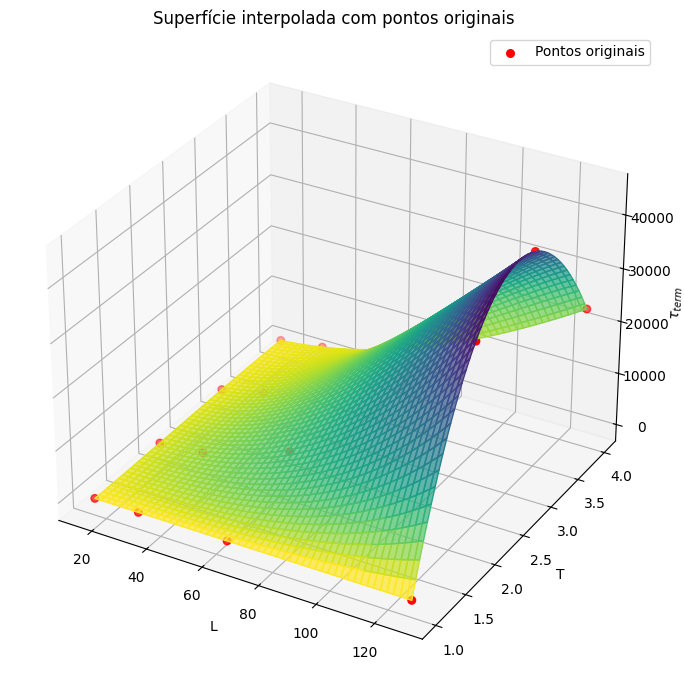

In [ ]:
L_vals = np.array(L_values)
T_vals = np.array(T_values)

tau_grid = np.array([
    [tau_use[(L, T)] for T in T_vals]
    for L in L_vals
])

# Para o erro: usa σ_τ nos fits ok, 0 para degenerate/unreliable
err_grid = np.array([
    [fit_errors[(L, T)][1] if fit_status[(L, T)] == 'ok' else 0.0
     for T in T_vals]
    for L in L_vals
])

interp_tau = RegularGridInterpolator((L_vals, T_vals), tau_grid, method="cubic")
interp_err = RegularGridInterpolator((L_vals, T_vals), err_grid, method="cubic")

def plot_region_with_Tstar_plane(L_min=None, L_max=None, T_min=None, T_max=None, dim=200):
    L_min = L_vals.min() if L_min is None else L_min
    L_max = L_vals.max() if L_max is None else L_max
    T_min = T_vals.min() if T_min is None else T_min
    T_max = T_vals.max() if T_max is None else T_max

    L_f = np.linspace(L_min, L_max, dim)
    T_f = np.linspace(T_min, T_max, dim)
    Lg, Tg = np.meshgrid(L_f, T_f, indexing="ij")
    pts = np.column_stack([Lg.ravel(), Tg.ravel()])

    tau_f = interp_tau(pts).reshape(Lg.shape)
    err_f = interp_err(pts).reshape(Lg.shape)

    # ── Pontos originais da interpolação ─────────────────────────────────
    mask = (
        (L_vals >= L_min) & (L_vals <= L_max)
    )
    L_pts, T_pts, tau_pts = [], [], []
    for L in L_vals[mask]:
        for T in T_vals:
            if T_min <= T <= T_max:
                L_pts.append(L)
                T_pts.append(T)
                tau_pts.append(tau_grid[np.where(L_vals == L)[0][0],
                                        np.where(T_vals == T)[0][0]])

    # ── Figura ───────────────────────────────────────────────────────────
    err_norm = err_f / (np.nanmax(err_f) + 1e-12)
    colors = plt.cm.viridis(1 - err_norm)
    colors[..., -1] = 1.0

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Superfície interpolada
    ax.plot_surface(Lg, Tg, tau_f, facecolors=colors, shade=False, alpha=0.7, zorder=1)

    # Pontos originais
    ax.scatter(L_pts, T_pts, tau_pts,
               color='red', s=30, zorder=5, label='Pontos originais')

    ax.set_xlabel("L")
    ax.set_ylabel("T")
    ax.set_zlabel(r"$\tau_{term}$")
    ax.set_title("Superfície interpolada com pontos originais")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_region_with_Tstar_plane(16, 128, 1, 4)

---
## Exercício 2 — Determinação da Temperatura Crítica

### 2(a)

Variando a temperatura de $T_{\min}=1$ a $T_{\max}=4$ em passos de $\Delta T=0.2$,
fazem-se $10^6$ medições da energia e magnetização para cada $T$ e cada
$L \in \{16, 32, 64, 128\}$.

Notas importantes:
- A magnetização é tomada em **valor absoluto** ($\langle |m| \rangle$). Para $T < T_c$
  o sistema finito pode flippar o sinal global de $M$ durante a simulação, levando
  $\langle m \rangle \to 0$ mesmo na fase ordenada; $\langle |m| \rangle$ é o parâmetro
  de ordem fisicamente correcto.
- Guardam-se também $\langle E \rangle$ e $\langle E^2 \rangle$ (energia **total**)
  para o cálculo da capacidade calorífica em 2(c) por flutuações.
- O tempo de termalização $\tau_\mathrm{use}$ vem do exercício 1, via o interpolador.
  É depois usado como $N_\mathrm{term} = 4\tau_\mathrm{use}$.

L=   128, T=  4.0000: 100%|██████████| 1000000/1000000 [00:02<00:00, 347953.57it/s]


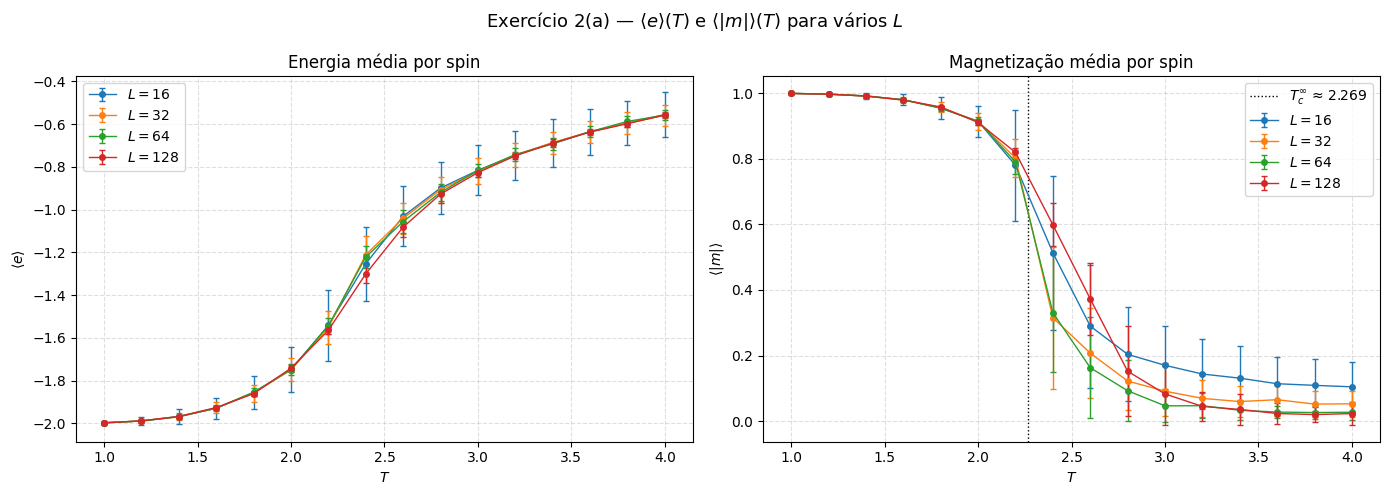

In [ ]:
T_values_2a = np.arange(1.0, 4.0 + 1e-9, 0.2)
n_meas      = 1_000_000

e_mean    = np.zeros((len(L_values), len(T_values_2a)))
e_std     = np.zeros_like(e_mean)
e_sq_mean = np.zeros_like(e_mean)
m_mean    = np.zeros_like(e_mean)
m_std     = np.zeros_like(e_mean)
E_mean    = np.zeros_like(e_mean)   # energia total para 2(c)
E_sq_mean = np.zeros_like(e_mean)   # idem

for iL, L in enumerate(L_values):
    for iT, T in enumerate(T_values_2a):

        tau_estimado = float(interp_tau([[L, T]])[0])
        if np.isnan(tau_estimado) or tau_estimado < 1.0:
            tau_estimado = 1.0
        n_term = max(1, int(4 * tau_estimado))

        model = IsingModel(L, T)
        model.iter_monte_carlo(n_term)   # termalização
        model.iter_monte_carlo(n_meas)   # medição

        e_arr = model.energy / L**2
        m_arr = model.magnetization

        e_mean   [iL, iT] = e_arr.mean()
        e_std    [iL, iT] = e_arr.std()
        e_sq_mean[iL, iT] = (e_arr**2).mean()

        E_mean   [iL, iT] = model.energy.mean()
        E_sq_mean[iL, iT] = (model.energy**2).mean()

        abs_m          = np.abs(m_arr)
        m_mean[iL, iT] = abs_m.mean()
        m_std [iL, iT] = abs_m.std()

# ── Gráficos ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    r"Exercício 2(a) — $\langle e \rangle(T)$ e $\langle |m| \rangle(T)$ para vários $L$",
    fontsize=13
)
cores = ["C0", "C1", "C2", "C3"]

for iL, L in enumerate(L_values):
    axes[0].errorbar(T_values_2a, e_mean[iL], yerr=e_std[iL],
                     marker="o", ms=4, lw=1, capsize=2,
                     color=cores[iL], label=f"$L = {L}$")
    axes[1].errorbar(T_values_2a, m_mean[iL], yerr=m_std[iL],
                     marker="o", ms=4, lw=1, capsize=2,
                     color=cores[iL], label=f"$L = {L}$")

Tc_inf = 2.0 / np.log(1.0 + np.sqrt(2.0))
axes[1].axvline(Tc_inf, color="k", ls=":", lw=1, label=f"$T_c^\\infty$ ≈ {Tc_inf:.3f}")

axes[0].set(xlabel="$T$", ylabel=r"$\langle e \rangle$", title="Energia média por spin")
axes[1].set(xlabel="$T$", ylabel=r"$\langle |m| \rangle$", title="Magnetização média por spin")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.4); ax.legend()

plt.tight_layout(); plt.show()

np.savez(
    "results_2a.npz",
    L_values  = np.array(L_values),
    T_values  = T_values_2a,
    e_mean    = e_mean, e_std = e_std, e_sq_mean = e_sq_mean,
    E_mean    = E_mean, E_sq_mean = E_sq_mean,
    m_mean    = m_mean, m_std = m_std,
)


### 2(b)

A capacidade calorífica é a derivada da energia em ordem à temperatura:

$$c = \frac{\partial e}{\partial T}$$

$T_c$ corresponde ao máximo de $c$, ou seja, ao zero da derivada $\partial c/\partial T$.

Propagação do erro para a derivada central:

$$\sigma_{\partial e / \partial T}^{i} = \frac{\sqrt{(\sigma_e^{i+1})^2 + (\sigma_e^{i-1})^2}}{2h}$$

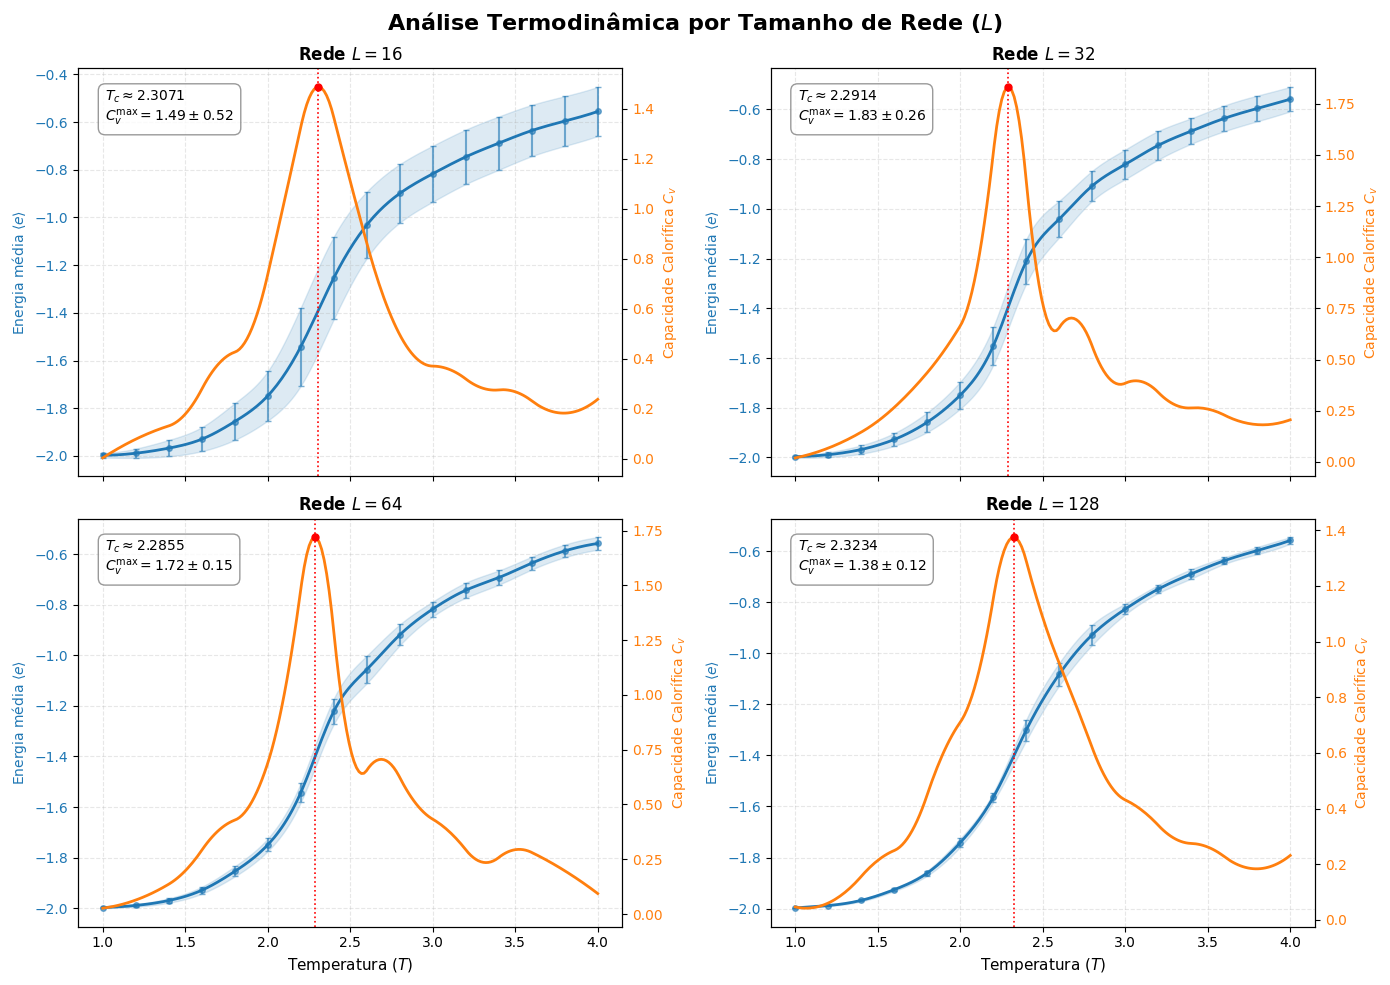

In [ ]:
E_func     = RegularGridInterpolator(
    (L_values, T_values_2a), e_mean,
    method="cubic", bounds_error=False, fill_value=None
)
E_std_func = RegularGridInterpolator(
    (L_values, T_values_2a), e_std,
    method="cubic", bounds_error=False, fill_value=None
)

def energy_temp(temp, L=128):
    temp = np.atleast_1d(temp)
    pontos = np.column_stack((np.full_like(temp, L), temp))
    return E_func(pontos)

def energy_std_temp(temp, L=128):
    temp = np.atleast_1d(temp)
    pontos = np.column_stack((np.full_like(temp, L), temp))
    return E_std_func(pontos)

def heat_cap_std(temp, L=128):
    spacing = T_values_2a[1] - T_values_2a[0]   # = 0.2
    return np.sqrt(energy_std_temp(temp + spacing, L)**2
                 + energy_std_temp(temp - spacing, L)**2) / (2 * spacing)

h_deriv = 1e-4   # passo da derivada central (sobre a spline interpolada)

def derivada(f):
    def der(x):
        return (f(x + h_deriv) - f(x - h_deriv)) / (2 * h_deriv)
    return der

def biss(a, b, f):
    epsilon = h_deriv
    x_ = (a + b) / 2
    thres = 0
    if f(a) * f(b) > 0:
        raise Exception("No root inside.")
    while np.abs(f(x_)) > epsilon:
        x_ = (a + b) / 2
        if f(x_) * f(a) <= 0:
            b = x_
        else:
            a = x_
        thres += 1
        if thres == 100:
            break
    return x_

def global_biss(f, f_der, step=0.2):
    zeros_found = []
    a = 1
    b = a + step
    while b <= 4:
        try:
            zero = biss(a, b, f_der)
            zeros_found.append(zero)
            a = b
            b += step
        except Exception:
            a = b
            b += step
            continue

    zeros_found_np = np.array(zeros_found)
    vals = f(zeros_found_np)
    xTc = np.argmax(vals)
    return zeros_found_np[xTc]

X_smooth = np.linspace(1.0, 4.0, 200)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle("Análise Termodinâmica por Tamanho de Rede ($L$)",
             fontsize=16, fontweight='bold')

config_L = [
    {"L": 16,  "row": 0, "col": 0},
    {"L": 32,  "row": 0, "col": 1},
    {"L": 64,  "row": 1, "col": 0},
    {"L": 128, "row": 1, "col": 1},
]

for config in config_L:
    L_atual = config["L"]
    row, col = config["row"], config["col"]
    ax_en = axes[row, col]
    ax_cv = ax_en.twinx()

    iL = L_values.index(L_atual)

    energy_local       = lambda t, L=L_atual: energy_temp(t, L=L)
    energy_std_local   = lambda t, L=L_atual: energy_std_temp(t, L=L)
    heat_cap_std_local = lambda t, L=L_atual: heat_cap_std(t, L=L)
    heat_cap_local     = derivada(energy_local)
    dc_local           = derivada(heat_cap_local)

    y_energy   = energy_local(X_smooth)
    err_energy = energy_std_local(X_smooth)
    y_cv       = heat_cap_local(X_smooth)
    err_cv     = heat_cap_std_local(X_smooth)

    try:
        c_atual      = global_biss(heat_cap_local, dc_local)
        cv_no_pico   = heat_cap_local(c_atual)[0]
        erro_cv_pico = heat_cap_std_local(c_atual)[0]
    except Exception:
        c_atual = None

    ax_en.errorbar(T_values_2a, e_mean[iL], yerr=e_std[iL], fmt='o', color='C0',
                   capsize=2, ms=4, alpha=0.6, label="Dados MC")
    ax_en.plot(X_smooth, y_energy, color='C0', lw=2, label=r"$\langle e \rangle$ Cúbico")
    ax_en.fill_between(X_smooth, y_energy - err_energy, y_energy + err_energy,
                       color='C0', alpha=0.15)
    ax_en.set_ylabel(r"Energia média $\langle e \rangle$", color='C0')
    ax_en.tick_params(axis='y', labelcolor='C0')
    ax_en.grid(True, ls="--", alpha=0.3)

    ax_cv.plot(X_smooth, y_cv, color='C1', lw=2, label=r"$C_v$ (Derivada)")
    ax_cv.set_ylabel(r"Capacidade Calorífica $C_v$", color='C1')
    ax_cv.tick_params(axis='y', labelcolor='C1')

    if c_atual is not None:
        ax_cv.axvline(c_atual, color="red", ls=":", lw=1.2)
        ax_cv.plot(c_atual, cv_no_pico, 'ro', ms=5)
        texto = (
            fr"$T_c \approx {c_atual:.4f}$" "\n"
            fr"$C_v^{{\max}} = {cv_no_pico:.2f} \pm {erro_cv_pico:.2f}$"
        )
        ax_en.text(0.05, 0.95, texto, transform=ax_en.transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                             alpha=0.8, edgecolor='gray'))

    ax_en.set_title(f"Rede $L = {L_atual}$", fontsize=12, fontweight='bold')
    if row == 1:
        ax_en.set_xlabel("Temperatura ($T$)", fontsize=11)

plt.tight_layout()
plt.show()

### 2(c)

Cálculo da capacidade calorífica pela base estatística do método de Metropolis-Hastings:

$$c = \frac{\langle E^2 \rangle - \langle E \rangle^2}{L^2 \, T^2}$$

Atenção: a equação usa a energia **total** $E$ (não a energia por spin $e = E/L^2$). Como
$E = L^2 \, e$, temos $\mathrm{Var}(E) = L^4 \, \mathrm{Var}(e)$, pelo que usar $e$ daria
um valor $L^2$ vezes mais pequeno.

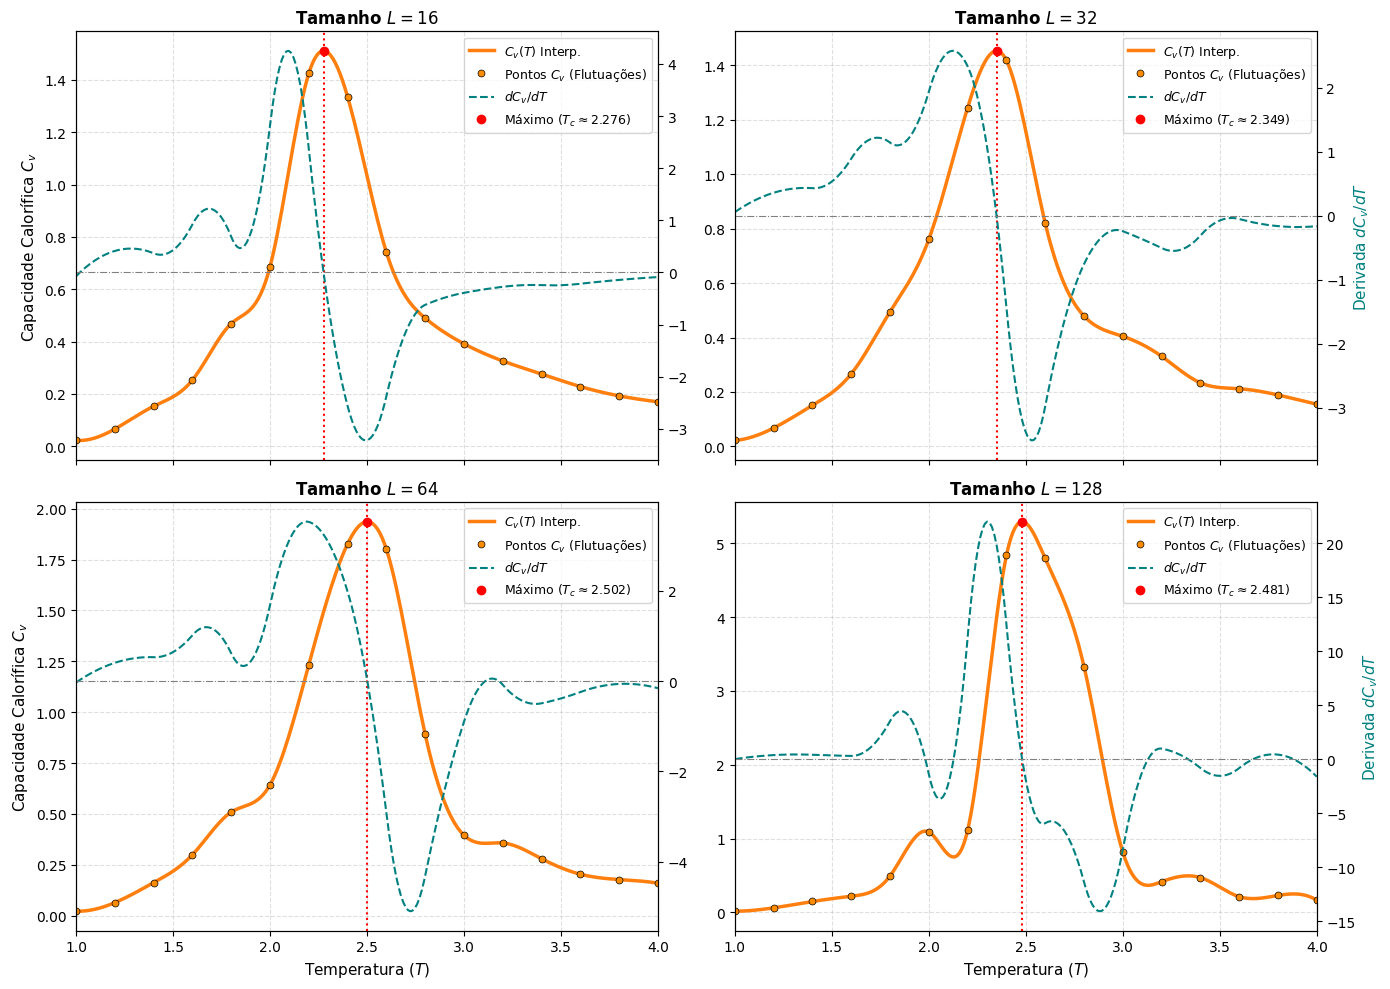

In [ ]:
def MetropolisHastings_heatCap(E_m, E_sq_m):
    L_arr = np.array(L_values)[:, np.newaxis]
    T_arr = T_values_2a[np.newaxis, :]
    return (E_sq_m - E_m**2) / (L_arr**2 * T_arr**2)

heat_cap_points = MetropolisHastings_heatCap(E_mean, E_sq_mean)

heat_cap_function = RegularGridInterpolator(
    (L_values, T_values_2a), heat_cap_points,
    method="cubic", bounds_error=False, fill_value=None
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

X_smooth = np.linspace(1, 4, 250)

for idx, L_alvo in enumerate([16, 32, 64, 128]):
    ax = axes[idx]
    iL = L_values.index(L_alvo)

    def heat_cap_function_1d_atual(temp, size=L_alvo):
        temp = np.atleast_1d(temp)
        pts  = np.column_stack([np.full_like(temp, size, dtype=float), temp])
        return heat_cap_function(pts)

    heat_cap_function_1d_der_atual = derivada(heat_cap_function_1d_atual)

    try:
        pico_atual = global_biss(heat_cap_function_1d_atual, heat_cap_function_1d_der_atual)
    except Exception:
        pico_atual = None

    Y_smooth_cv  = heat_cap_function_1d_atual(X_smooth)
    Y_smooth_der = np.array([float(heat_cap_function_1d_der_atual(t)) for t in X_smooth])

    line1, = ax.plot(X_smooth, Y_smooth_cv, color='C1', lw=2.5, label="$C_v(T)$ Interp.")
    line2, = ax.plot(T_values_2a, heat_cap_points[iL], 'o', color='darkorange',
                     ms=5, mec='k', mew=0.5, label="Pontos $C_v$ (Flutuações)")

    ax_der = ax.twinx()
    line3, = ax_der.plot(X_smooth, Y_smooth_der, color='teal', lw=1.5, ls="--", label="$dC_v/dT$")
    ax_der.axhline(0, color='gray', lw=0.8, ls="-.")

    linhas = [line1, line2, line3]
    if pico_atual is not None:
        ax.axvline(x=pico_atual, color='red', linestyle=':', lw=1.5)
        cv_pico = float(heat_cap_function_1d_atual(np.array([pico_atual]))[0])
        line4, = ax.plot(pico_atual, cv_pico, 'ro', ms=6,
                         label=f"Máximo ($T_c \\approx {pico_atual:.3f}$)")
        linhas.append(line4)

    ax.set_title(f"Tamanho $L = {L_alvo}$", fontsize=12, fontweight='bold')
    ax.set_xlim(1.0, 4.0)
    ax.grid(True, ls="--", alpha=0.4)

    if idx in [2, 3]:
        ax.set_xlabel("Temperatura ($T$)", fontsize=11)
    if idx in [0, 2]:
        ax.set_ylabel(r"Capacidade Calorífica $C_v$", fontsize=11)
    if idx in [1, 3]:
        ax_der.set_ylabel(r"Derivada $dC_v/dT$", fontsize=11, color='teal')

    legendas = [l.get_label() for l in linhas]
    ax.legend(linhas, legendas, loc="upper right", fontsize=9, frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

Comparação dos resultados através do método estatístico e através do método analítico.

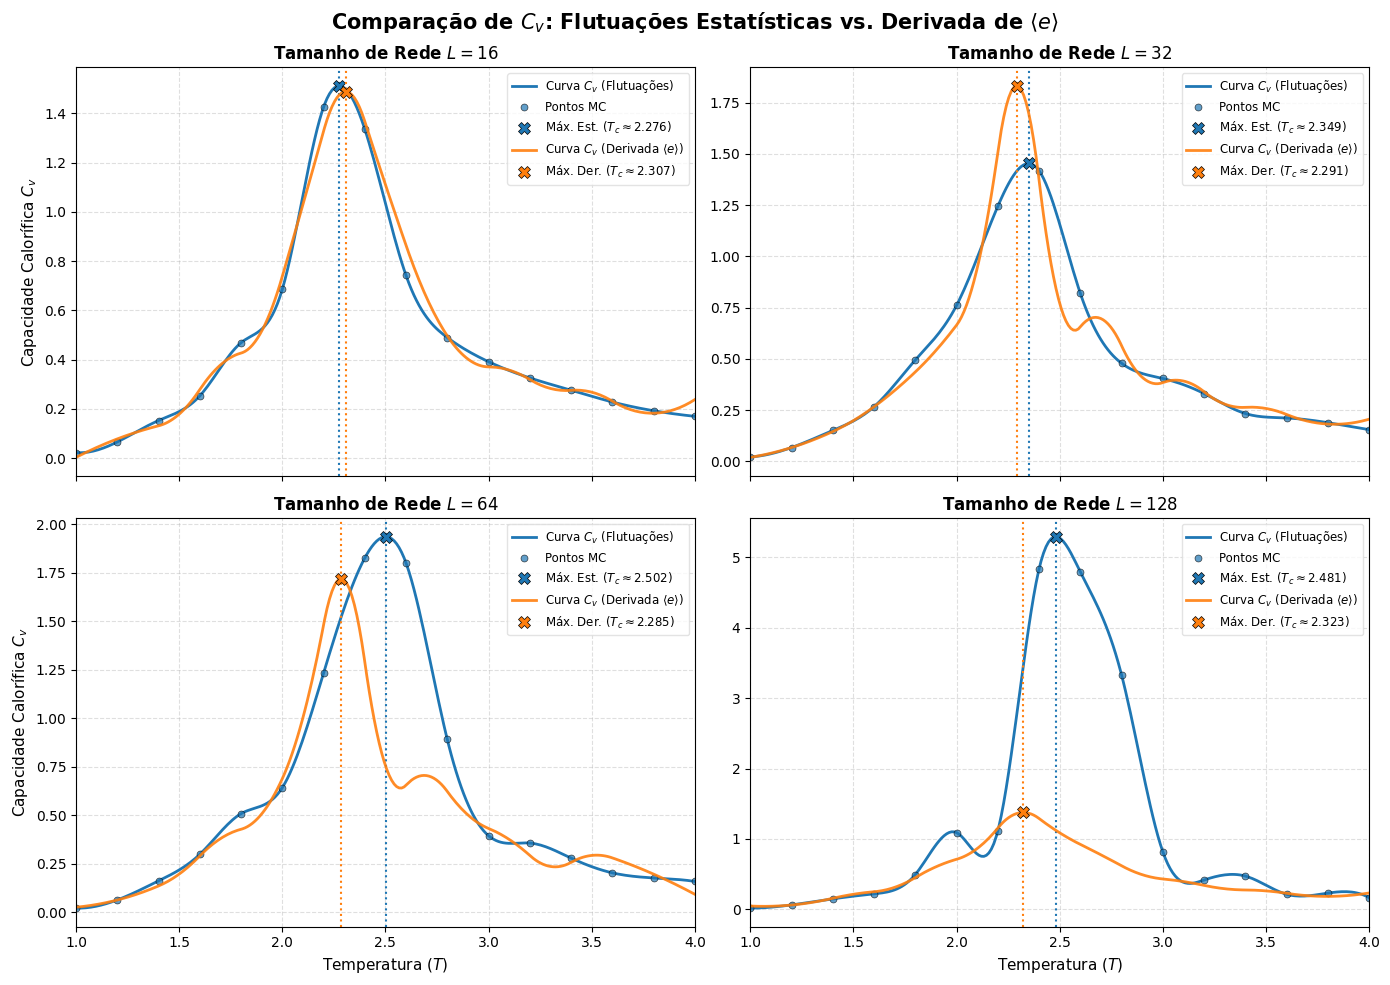

         COMPARAÇÃO DOS RESULTADOS: ESTATÍSTICO vs ANALÍTICO          
Tamanho de Rede: L = 16
  ➤ Método Estatístico : Tc = 2.27599  |  Cv_max = 1.5110
  ➤ Método Analítico   : Tc = 2.30708  |  Cv_max = 1.4882
  ➤ Diferenças absolutas: ΔTc = 0.03109  |  ΔCv_max = 0.0228
----------------------------------------------------------------------
Tamanho de Rede: L = 32
  ➤ Método Estatístico : Tc = 2.34918  |  Cv_max = 1.4533
  ➤ Método Analítico   : Tc = 2.29137  |  Cv_max = 1.8318
  ➤ Diferenças absolutas: ΔTc = 0.05781  |  ΔCv_max = 0.3784
----------------------------------------------------------------------
Tamanho de Rede: L = 64
  ➤ Método Estatístico : Tc = 2.50173  |  Cv_max = 1.9365
  ➤ Método Analítico   : Tc = 2.28546  |  Cv_max = 1.7201
  ➤ Diferenças absolutas: ΔTc = 0.21627  |  ΔCv_max = 0.2164
----------------------------------------------------------------------
Tamanho de Rede: L = 128
  ➤ Método Estatístico : Tc = 2.48099  |  Cv_max = 5.2936
  ➤ Método Analítico   : Tc = 

In [ ]:
X_smooth = np.linspace(1.0, 4.0, 250)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle("Comparação de $C_v$: Flutuações Estatísticas vs. Derivada de $\\langle e \\rangle$",
             fontsize=15, fontweight='bold')
axes = axes.flatten()

# Guardar resultados para reutilizar no print
resultados = {}

for idx, L_alvo in enumerate(L_values):
    ax = axes[idx]

    # ── Método estatístico — flutuações 2(c) ─────────────────────────────
    def heat_cap_function_1d_atual(temp, size=L_alvo):
        temp = np.atleast_1d(temp)
        pts  = np.column_stack([np.full_like(temp, size, dtype=float), temp])
        return heat_cap_function(pts)

    heat_cap_function_1d_der_atual = derivada(heat_cap_function_1d_atual)
    Y_smooth_cv_stat = heat_cap_function_1d_atual(X_smooth)

    try:
        pico_stat    = global_biss(heat_cap_function_1d_atual, heat_cap_function_1d_der_atual)
        cv_pico_stat = float(heat_cap_function_1d_atual(np.array([pico_stat]))[0])
    except Exception:
        pico_stat    = None
        cv_pico_stat = float('nan')

    # ── Método analítico — derivada de e, 2(b) ───────────────────────────
    energy_local   = lambda t, L=L_alvo: energy_temp(t, L=L)
    heat_cap_local = derivada(energy_local)
    dc_local       = derivada(heat_cap_local)

    Y_smooth_cv_deriv = heat_cap_local(X_smooth)

    try:
        pico_deriv    = global_biss(heat_cap_local, dc_local)
        cv_pico_deriv = float(np.atleast_1d(heat_cap_local(pico_deriv))[0])
    except Exception:
        pico_deriv    = None
        cv_pico_deriv = float('nan')

    # Guardar para o print abaixo
    resultados[L_alvo] = (pico_stat, cv_pico_stat, pico_deriv, cv_pico_deriv)

    # ── Gráfico ───────────────────────────────────────────────────────────
    linhas_legenda = []

    line1, = ax.plot(X_smooth, Y_smooth_cv_stat, color='C0', lw=2,
                     label="Curva $C_v$ (Flutuações)")
    line2, = ax.plot(T_values_2a, heat_cap_points[idx], 'o', color='C0', ms=5,
                     alpha=0.7, mec='k', mew=0.5, label="Pontos MC")
    linhas_legenda.extend([line1, line2])

    if pico_stat is not None:
        ax.axvline(x=pico_stat, color='C0', linestyle=':', lw=1.5)
        line3, = ax.plot(pico_stat, cv_pico_stat, 'X', color='C0', ms=8,
                         mec='k', mew=0.5,
                         label=f"Máx. Est. ($T_c \\approx {pico_stat:.3f}$)")
        linhas_legenda.append(line3)

    line4, = ax.plot(X_smooth, Y_smooth_cv_deriv, color='C1', lw=2,
                     linestyle='-', alpha=0.9,
                     label="Curva $C_v$ (Derivada $\\langle e \\rangle$)")
    linhas_legenda.append(line4)

    if pico_deriv is not None:
        ax.axvline(x=pico_deriv, color='C1', linestyle=':', lw=1.5)
        line5, = ax.plot(pico_deriv, cv_pico_deriv, 'X', color='C1', ms=8,
                         mec='k', mew=0.5,
                         label=f"Máx. Der. ($T_c \\approx {pico_deriv:.3f}$)")
        linhas_legenda.append(line5)

    ax.set_title(f"Tamanho de Rede $L = {L_alvo}$", fontsize=12, fontweight='bold')
    ax.set_xlim(1.0, 4.0)
    ax.grid(True, ls="--", alpha=0.4)

    if idx in [2, 3]:
        ax.set_xlabel("Temperatura ($T$)", fontsize=11)
    if idx in [0, 2]:
        ax.set_ylabel(r"Capacidade Calorífica $C_v$", fontsize=11)

    legendas = [l.get_label() for l in linhas_legenda]
    ax.legend(linhas_legenda, legendas, loc="upper right", fontsize=8.5,
              frameon=True, facecolor='white', edgecolor='gainsboro')

plt.tight_layout()
plt.show()

# ── Print — reutiliza resultados já calculados ────────────────────────────────
print("=" * 70)
print(f"{'COMPARAÇÃO DOS RESULTADOS: ESTATÍSTICO vs ANALÍTICO':^70}")
print("=" * 70)

for L_alvo in L_values:
    pico_stat, cv_pico_stat, pico_deriv, cv_pico_deriv = resultados[L_alvo]
    print(f"Tamanho de Rede: L = {L_alvo}")

    if pico_stat is not None and pico_deriv is not None:
        diff_Tc = abs(pico_stat - pico_deriv)
        diff_Cv = abs(cv_pico_stat - cv_pico_deriv)
        print(f"  ➤ Método Estatístico : Tc = {pico_stat:.5f}  |  Cv_max = {cv_pico_stat:.4f}")
        print(f"  ➤ Método Analítico   : Tc = {pico_deriv:.5f}  |  Cv_max = {cv_pico_deriv:.4f}")
        print(f"  ➤ Diferenças absolutas: ΔTc = {diff_Tc:.5f}  |  ΔCv_max = {diff_Cv:.4f}")
    else:
        print("  [!] Erro: Falha na convergência para este tamanho de rede.")

    print("-" * 70)

2d) Fit dos dados obtidos anteriormente da capacidade calorífica ao modelo:
$$c \approx A\ln|\frac{T-T_c}{T}|+B$$
Através do método curve_fit do módulo scipy.optimize vamos fazer esse fit para a capacidade calorífica em função da temperatura para cada um dos tamanhos de lattice estudado.

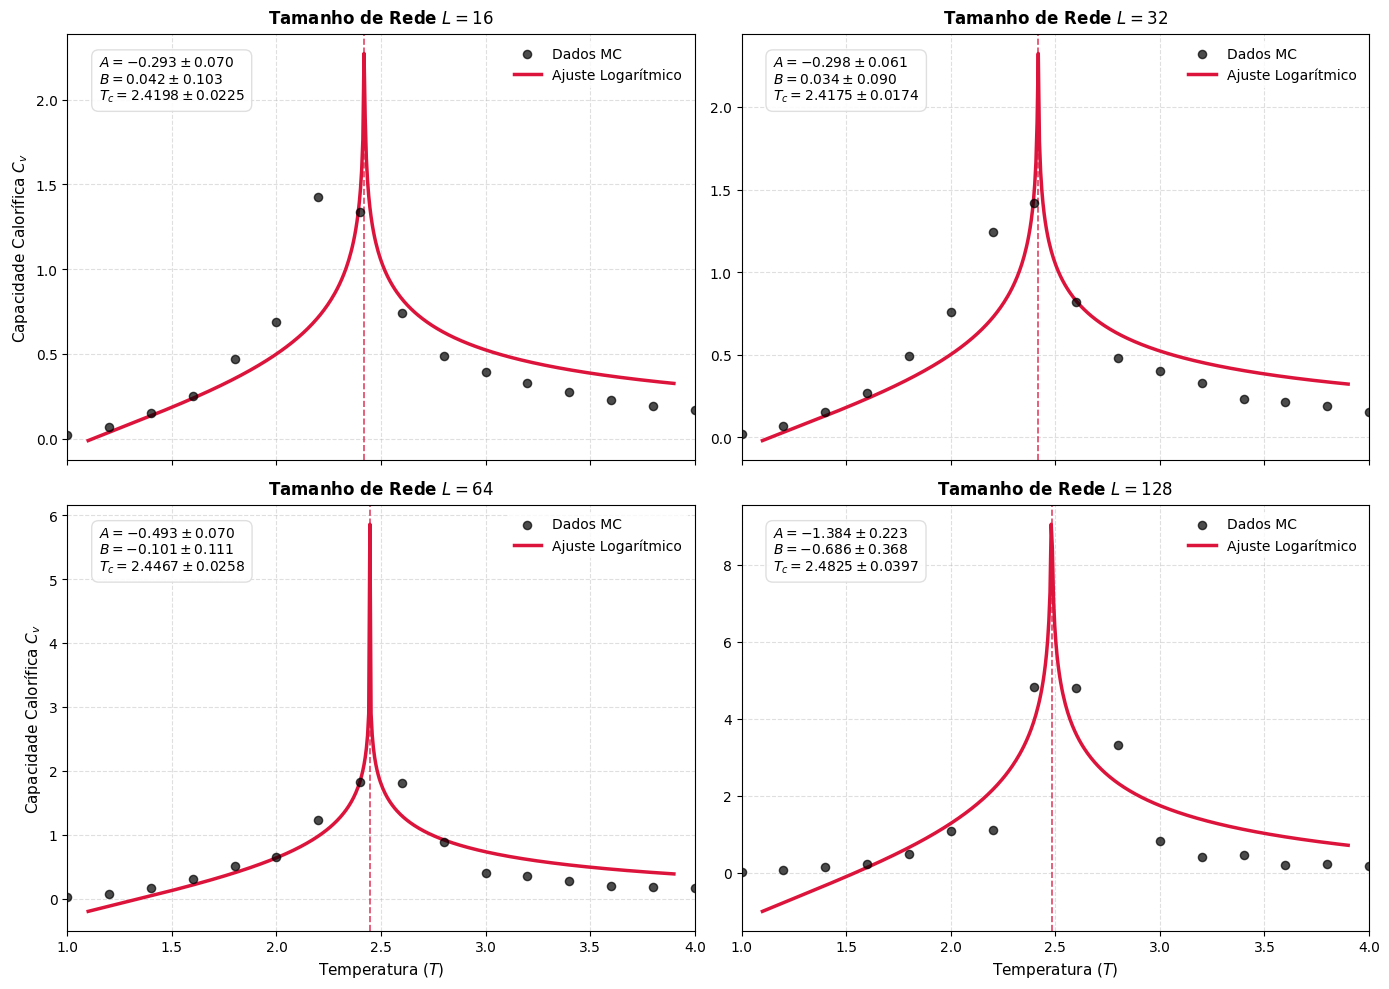

In [ ]:
def heat_cap_model(T, A, B, Tc):
    return A*np.log(np.abs((T-Tc)/T))+B

fits = {}

for iL, L in enumerate(L_values):
    heat_for_t = heat_cap_points[iL]
    try:
        #p0 = [1, 1, 1]
        limites = ([-np.inf, -np.inf, 1], [np.inf, np.inf, 4])
        popt, pcov = curve_fit(heat_cap_model, T_values_2a, heat_for_t, 
                                bounds=limites, maxfev=1000000)

        perr = np.sqrt(np.diag(pcov))

        fits[L] = [popt, perr]

    except (RuntimeError, ValueError):
        print(f"Fit nao convergiu para L={L}.")
        popt = np.full(3, np.nan)
        perr = np.full(3, np.nan)

        fits[L] = [popt, perr]

# Criar uma matriz de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

# Gerar um vetor denso de temperaturas para desenhar a curva do fit de forma suave
T_smooth = np.linspace(1.1, 3.9, 500)

for idx, L in enumerate(L_values):
    ax = axes[idx]
    
    # Extrair os dados originais deste L
    strained_points = heat_cap_points[idx]
    ax.scatter(T_values_2a, strained_points, color='black', alpha=0.7, 
               edgecolors='k', s=35, zorder=3, label="Dados MC")
    
    # Verificar se o fit deste L correu bem (se temos valores válidos em fits)
    if L in fits and not np.isnan(fits[L][0][0]):
        popt, perr = fits[L]
        A_opt, B_opt, Tc_opt = popt
        A_err, B_err, Tc_err = perr
        
        # 1. Desenhar a curva do ajuste matemático
        Y_smooth = heat_cap_model(T_smooth, A_opt, B_opt, Tc_opt)
        ax.plot(T_smooth, Y_smooth, color='crimson', lw=2.5, label="Ajuste Logarítmico")
        
        # 2. Adicionar linha vertical no Tc estimado
        ax.axvline(x=Tc_opt, color='crimson', ls='--', lw=1.2, alpha=0.8)
        
        # 3. Criar uma caixa de texto elegante com os resultados do Fit
        texto_fit = (
            f"$A = {A_opt:.3f} \\pm {A_err:.3f}$\n"
            f"$B = {B_opt:.3f} \\pm {B_err:.3f}$\n"
            f"$T_c = {Tc_opt:.4f} \\pm {Tc_err:.4f}$"
        )
        props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gainsboro', alpha=0.9)
        ax.text(0.05, 0.95, texto_fit, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props, fontfamily='monospace')
                
    else:
        # Caso o fit tenha falhado ("Nuh uh")
        ax.text(0.5, 0.5, "Ajuste Não Convergiu", color='gray', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12, style='italic')

    # Decorações estéticas por gráfico
    ax.set_title(f"Tamanho de Rede $L = {L}$", fontsize=12, fontweight='bold', pad=8)
    ax.set_xlim(1.0, 4.0)
    ax.grid(True, ls="--", alpha=0.4, zorder=0)
    ax.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='none')

    # Atribuição cirúrgica de labels aos eixos para não sobrecarregar a imagem
    if idx in [2, 3]:
        ax.set_xlabel("Temperatura ($T$)", fontsize=11)
    if idx in [0, 2]:
        ax.set_ylabel(r"Capacidade Calorífica $C_v$", fontsize=11)

# Ajuste fino do espaçamento do layout e apresentação
plt.tight_layout()
plt.show()


---
## Exercicio 3 - Energia Livre de Helmholtz, $F(T)$

A energia livre de Helmholtz e calculada numericamente a partir da identidade
de Gibbs-Helmholtz $\partial(F/T)/\partial T = -E/T^2$, integrada entre $T$ e
$+\infty$ com a condicao de fronteira $F/T \to -N\ln 2$ quando $T\to\infty$
(entropia de spins independentes):

$$
F(T) \;=\; T\!\int_T^{\infty}\!\frac{E(T')}{T'^{2}}\,dT' \;-\; NT\ln 2.
$$

Numericamente, truncamos em $T = 10$ (o integrando $E/T'^2 \to 0$ rapidamente):

$$
F(T) \;\approx\; T\!\left[\int_T^{10}\frac{E(T')}{T'^{2}}\,dT' - N\ln 2\right]
\quad (T < 10).
$$

**Verificacao de consistencia em $T=10$:** o integral anula-se, dando
$F(10) = 10\cdot(0 - N\ln 2) = -10\,N\ln 2$, igual ao limite paramagnético. $F(T)$
e **sempre negativa**, indo de $F(0) \to -2N$ (estado fundamental) ate
$F(10) \approx -6{,}93\,N$ (limite paramagnético).

**Reaproveitamento de dados do exercicio 2:**
O ex. 2(a) ja calculou $\langle E\rangle$ e $\langle E^{2}\rangle$ para $L=128$
em $T\in\{1{,}0, 1{,}2,\dots, 4{,}0\}$ com $10^{6}$ medicoes por temperatura.
Esses 16 pontos coincidem com a grelha pretendida e tem **estatistica 5x melhor**
do que seria praticavel recalcular. Reutilizam-se directamente; simulam-se apenas
os $100-16=84$ pontos em falta.

A integracao numerica usa o metodo dos trapezios via `cumulative_trapezoid`.


### 3(a) - Simulacoes e calculo de $F(T)$ por integracao dos trapezios

Reaproveitados 16 pontos do ex.2(a) (T in [1.0, 4.0], 10^6 medicoes/T)
A simular 84 pontos novos (200_000 medicoes/T)



L=   128, T= 10.0000: 100%|██████████| 200000/200000 [00:01<00:00, 120063.83it/s]



Validacao em T = 10:
   F(10) calculado:    -113565.2341
   -10*N*ln2 esperado: -113565.2341    (devem coincidir)


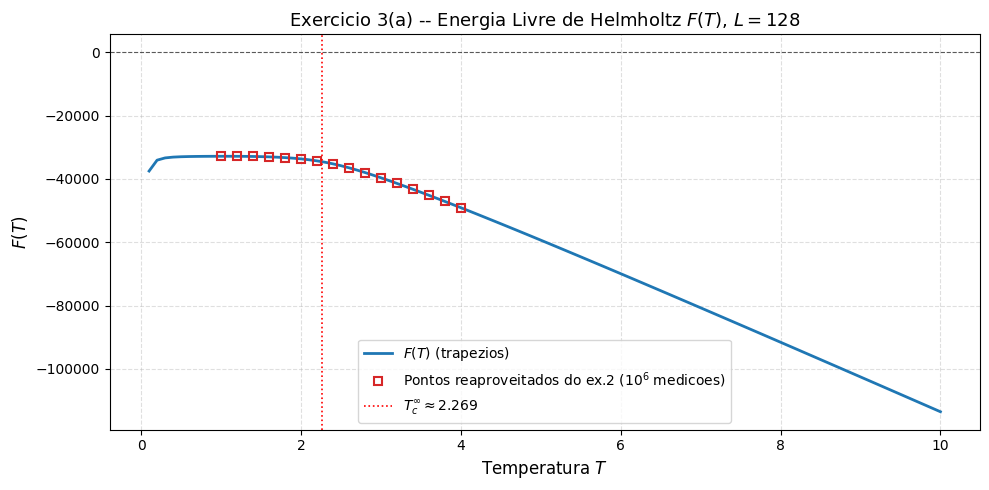


3(a) concluido. Resultados guardados em results_3a.npz.


In [ ]:
# == 3(a) - Simulacoes para L=128, T in [0.1, 10.0], dT=0.1 ==
L_3      = 128
N_3      = L_3**2
T_3      = np.round(np.arange(0.1, 10.0 + 1e-9, 0.1), 6)    # 100 temperaturas
n_meas_3 = 200_000                                          # medicoes por T (so para os pontos novos)

# Termalizacao: usa tau_use do ex.1 quando T in [1,4]; senao usa tau=1.
# Garante-se um piso de 5 sweeps (5*L^2) para L=128 estar bem termalizado.
n_term_min = 5 * L_3**2

# -- Reaproveitar dados do ex.2(a) para L=128 --------------------------------
# T_values_2a = [1.0, 1.2, ..., 4.0]  ja calculado com 10^6 medicoes
iL_128       = L_values.index(128)
T_existentes = np.round(np.asarray(T_values_2a), 6)
E_existentes  = E_mean   [iL_128]   # <E>  (energia total) -- guardado em 2(a)
E2_existentes = E_sq_mean[iL_128]   # <E^2>

# Construir mapa T -> (E, E2) com os valores ja existentes do ex.2
ja_calculado = {float(T): (float(E_existentes[k]), float(E2_existentes[k]))
                for k, T in enumerate(T_existentes)}

print(f"Reaproveitados {len(ja_calculado)} pontos do ex.2(a) (T in [1.0, 4.0], 10^6 medicoes/T)")
print(f"A simular {len(T_3) - len(ja_calculado)} pontos novos (200_000 medicoes/T)")
print()

# -- Loop principal ---------------------------------------------------------
E_3  = np.zeros(len(T_3))
E2_3 = np.zeros(len(T_3))

for iT, T in enumerate(T_3):
    T_key = float(np.round(T, 6))

    # Reaproveitar valor do ex.2 se existir
    if T_key in ja_calculado:
        E_3[iT], E2_3[iT] = ja_calculado[T_key]
        continue

    # Caso contrario, simular: termalizacao usando tau interpolado
    T_clamp = float(np.clip(T, T_values_2a[0], T_values_2a[-1]))
    try:
        tau_est = float(interp_tau([[L_3, T_clamp]])[0])
        tau_est = max(1.0, tau_est) if not np.isnan(tau_est) else 1.0
    except Exception:
        tau_est = 1.0
    n_term = max(int(4 * tau_est), n_term_min)

    model = IsingModel(L_3, T)
    model.iter_monte_carlo(n_term)     # termalizacao
    model.iter_monte_carlo(n_meas_3)   # medicao

    E_3 [iT] = model.energy.mean()
    E2_3[iT] = (model.energy**2).mean()

# -- Integração pelos trapézios ----------------------------------------------
integrand_3 = E_3 / T_3**2                                        # f(T) = E/T^2
cumint_3    = cumulative_trapezoid(integrand_3, T_3, initial=0)   # int[0.1 -> T]
total_int   = cumint_3[-1]                                         # int[0.1 -> 10]
int_T_to_10 = total_int - cumint_3                                 # int[T -> 10]  ≈ int[T -> ∞]

# F(T) = T * [ int(T -> ∞) - N*ln2 ]
F_3 = T_3 * (int_T_to_10 - N_3 * np.log(2))  

# -- Validacao da fronteira em T=10 ------------------------------------------
F_boundary_esperado = -T_3[-1] * N_3 * np.log(2)
print(f"\nValidacao em T = 10:")
print(f"   F(10) calculado:    {F_3[-1]:+.4f}")
print(f"   -10*N*ln2 esperado: {F_boundary_esperado:+.4f}    (devem coincidir)")

# -- Grafico ----------------------------------------------------------------
Tc_inf = 2.0 / np.log(1.0 + np.sqrt(2.0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(T_3, F_3, lw=2, color="C0", label=r"$F(T)$ (trapezios)")
# Marcar os pontos reaproveitados do ex.2
idx_reap = [i for i, T in enumerate(T_3) if float(np.round(T, 6)) in ja_calculado]
ax.plot(T_3[idx_reap], F_3[idx_reap], "s", ms=6, mfc="none", mec="C3", mew=1.5,
        label=r"Pontos reaproveitados do ex.2 ($10^6$ medicoes)")
ax.axhline(0,      color="k",   lw=0.8, ls="--", alpha=0.6)
ax.axvline(Tc_inf, color="red", lw=1.2, ls=":",
           label=fr"$T_c^\infty \approx {Tc_inf:.3f}$")
ax.set_xlabel(r"Temperatura $T$", fontsize=12)
ax.set_ylabel(r"$F(T)$",          fontsize=12)
ax.set_title(r"Exercicio 3(a) -- Energia Livre de Helmholtz $F(T)$, $L=128$",
             fontsize=13)
ax.legend(fontsize=10); ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout(); plt.show()

np.savez("results_3a.npz", T_3=T_3, E_3=E_3, E2_3=E2_3, F_3=F_3)
print("\n3(a) concluido. Resultados guardados em results_3a.npz.")

### 3(b) - Spline cubica de $F(T)$ e raiz $F(T^*) = -4N$ por bissetriz

Interpola-se $F(T)$ com uma *spline* cubica (`CubicSpline`) e aplica-se o metodo
da bissetriz para encontrar $T^{*}$ tal que $F(T^{*}) = -4N$.

**Existencia e unicidade da solucao.** Como $F$ e monotonamente decrescente
($\partial F/\partial T = -S < 0$ pois $S \geq 0$):

- $F(T \to 0) \to -2N > -4N$ (estado fundamental, energia domina a entropia);
- $F(10) = -10\,N\ln 2 \approx -6{,}93\,N < -4N$ (regime paramagnético).

Como $F$ e continua e estritamente decrescente, existe exactamente um $T^*$
no intervalo $(0{,}1;\,10)$ tal que $F(T^*) = -4N$.


Raiz de F(T*) = -4N = -65536:
   T* = 5.58644442    F(T*) = -6.554e+04


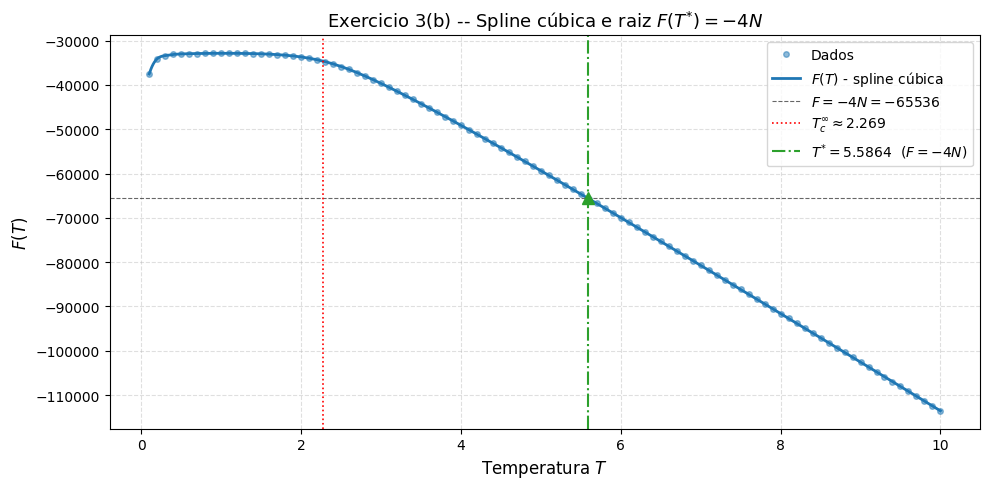

In [ ]:
# == 3(b) - Spline cubica + bissetriz ==
cs_F = CubicSpline(T_3, F_3)

T_fine  = np.linspace(T_3[0], T_3[-1], 2000)
F_fine  = cs_F(T_fine)
target  = -4.0 * N_3

# Procurar mudancas de sinal de F(T) - target e refinar por bissetriz
zeros_F = []
g_fine  = F_fine - target
for k in range(len(g_fine) - 1):
    if g_fine[k] * g_fine[k + 1] < 0:
        T_root = biss(T_fine[k], T_fine[k + 1], lambda T: cs_F(T) - target)
        zeros_F.append(T_root)

print(f"Raiz de F(T*) = -4N = {target:.0f}:")
for T_root in zeros_F:
    print(f"   T* = {T_root:.8f}    F(T*) = {float(cs_F(T_root)):+.3e}")

# -- Grafico ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(T_3,    F_3,    "o", ms=4, alpha=0.5, color="C0", label="Dados")
ax.plot(T_fine, F_fine, lw=2,                  color="C0", label=r"$F(T)$ - spline cúbica")
ax.axhline(target, color="k", lw=0.8, ls="--", alpha=0.6,
           label=fr"$F = -4N = {target:.0f}$")
ax.axvline(Tc_inf, color="red", lw=1.2, ls=":",
           label=fr"$T_c^\infty \approx {Tc_inf:.3f}$")
for T_root in zeros_F:
    ax.axvline(T_root, color="C2", lw=1.5, ls="-.",
               label=fr"$T^{{*}} = {T_root:.4f}$  ($F = -4N$)")
    ax.plot(T_root, target, "^", ms=9, color="C2", zorder=5)
ax.set_xlabel(r"Temperatura $T$", fontsize=12)
ax.set_ylabel(r"$F(T)$",          fontsize=12)
ax.set_title(r"Exercicio 3(b) -- Spline cúbica e raiz $F(T^{*}) = -4N$", fontsize=13)
ax.legend(fontsize=10); ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout(); plt.show()

### 3(c) - Segunda derivada de $F(T)$ e comportamento em $T_c$

Calcula-se $\partial^{2}F/\partial T^{2}$ atraves de `.derivative(2)` da
`CubicSpline` (derivada **exacta** em cada segmento cubico, sem ruido de
diferencas finitas).

**Derivacao.** Com $F(T)= T\,[g(T)-N\ln 2]$, onde
$g(T)=\int_{T}^{10}E/T'^{2}\,dT'$ e $g'(T)=-E(T)/T^{2}$:

$$
\frac{\partial F}{\partial T} \;=\; g(T) + T\,g'(T) - N\ln 2
\;=\; g(T) - \frac{E(T)}{T} - N\ln 2 \;=\; -S(T),
$$

$$
\frac{\partial^{2} F}{\partial T^{2}} \;=\; g'(T) - \frac{E'(T)\,T - E(T)}{T^2}
\;=\; -\frac{E(T)}{T^2} - \frac{E'(T)}{T} + \frac{E(T)}{T^2}
\;=\; -\frac{E'(T)}{T} \;=\; -\frac{N\,c(T)}{T}.
$$

Portanto $\partial^{2}F/\partial T^{2} = -Nc/T < 0$ — **proporcional em modulo
a capacidade calorifica**. Em $T_c$, $c$ tem um **maximo** acentuado
(divergencia logaritmica suavizada pelo tamanho finito $L=128$), o que corresponde
a um **minimo** de $\partial^2 F/\partial T^2$.

**Validacao cruzada:** a quantidade $-(T/N)\,\partial^{2}F/\partial T^{2}$
deve coincidir (a menos de ruido estatistico) com $c(T)$ obtida pelas
flutuacoes $(\langle E^{2}\rangle-\langle E\rangle^{2})/(L^2 T^2)$ do Ex. 2(c).


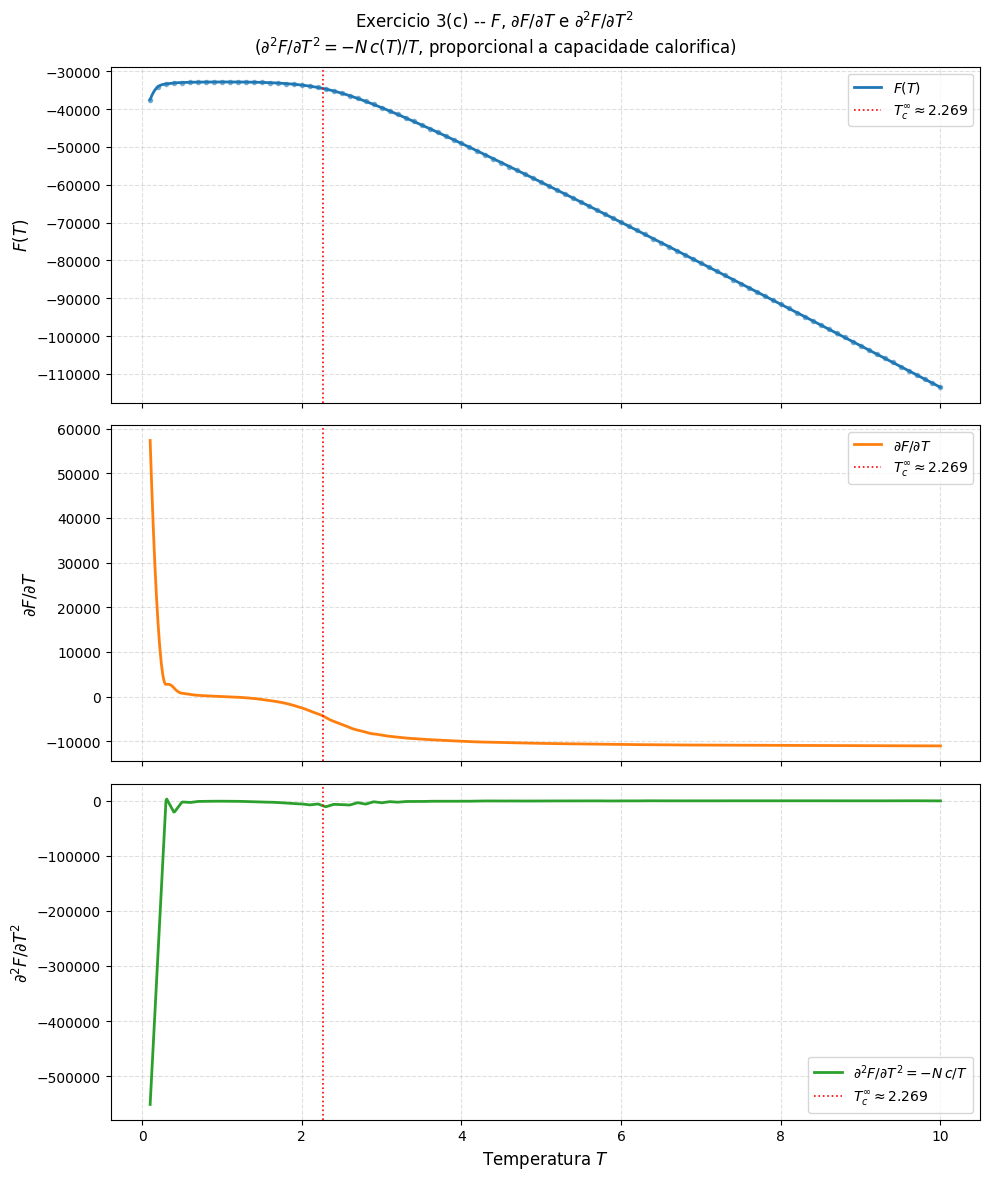

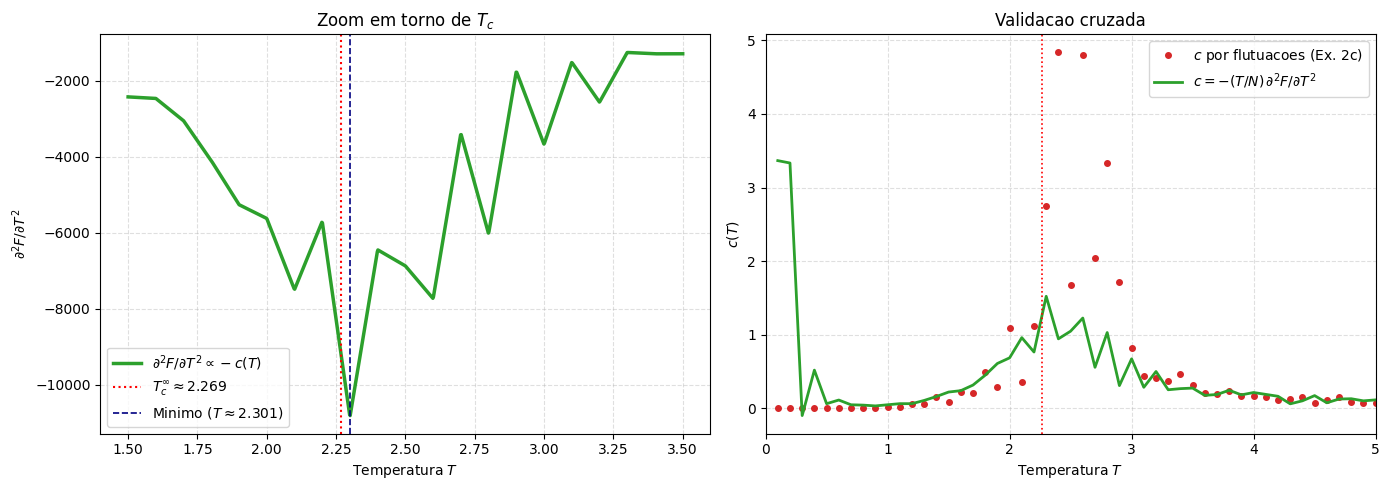

ANALISE DO COMPORTAMENTO EM TORNO DE T_c

Da expressao  F(T) = T * [int_T^inf E/T'^2 dT' - N*ln2]  obtem-se,
derivando duas vezes:

    d2F/dT2 = -E'(T)/T = -N * c(T) / T

ou seja, -d2F/dT2 e proporcional a capacidade calorifica c(T),
e o pico de c corresponde a um MINIMO de d2F/dT2.

Junto a T_c, c diverge logaritmicamente no limite termodinamico
(solucao exacta de Onsager); para L=128 finito, observa-se um pico
acentuado mas finito.

   T_c (sistema infinito, Onsager): 2.269185
   T_c (minimo de d2F/dT2):         2.300801

A concordancia entre as duas estimativas de c (painel da direita)
valida simultaneamente a integracao por trapezios, a interpolacao por
spline cubica, e a derivacao analitica.


In [ ]:
# == 3(c) - Segunda derivada da spline e validacao ==
cs_dF  = cs_F.derivative(1)        # dF/dT
cs_d2F = cs_F.derivative(2)        # d2F/dT2 = -N * c(T) / T

T_plot   = np.linspace(T_3[0], T_3[-1], 1000)
F_vals   = cs_F  (T_plot)
dF_vals  = cs_dF (T_plot)
d2F_vals = cs_d2F(T_plot)

# -- Figura com 3 paineis ---------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle(
    r"Exercicio 3(c) -- $F$, $\partial F/\partial T$ e $\partial^2 F/\partial T^2$"
    "\n" r"($\partial^2 F/\partial T^2 = -N\,c(T)/T$, proporcional a capacidade calorifica)",
    fontsize=12
)

axes[0].plot(T_3,    F_3,    "o", ms=3, alpha=0.5, color="C0")
axes[0].plot(T_plot, F_vals, lw=2, color="C0", label=r"$F(T)$")
axes[0].set_ylabel(r"$F(T)$", fontsize=12)

axes[1].plot(T_plot, dF_vals, lw=2, color="C1",
             label=r"$\partial F/\partial T$")
axes[1].set_ylabel(r"$\partial F/\partial T$", fontsize=12)

axes[2].plot(T_plot, d2F_vals, lw=2, color="C2",
             label=r"$\partial^2 F/\partial T^2 = -N\,c/T$")
axes[2].set_ylabel(r"$\partial^2 F/\partial T^2$", fontsize=12)
axes[2].set_xlabel(r"Temperatura $T$", fontsize=12)

for ax in axes:
    ax.axvline(Tc_inf, color="red", lw=1.2, ls=":",
               label=fr"$T_c^\infty \approx {Tc_inf:.3f}$")
    ax.grid(True, ls="--", alpha=0.4); ax.legend(fontsize=10)

plt.tight_layout(); plt.show()

# -- Pico de c <=> MINIMO de d2F/dT2 --------------------------------------
T_zoom   = np.linspace(1.5, 3.5, 1000)
d2F_zoom = cs_d2F(T_zoom)
idx_pico = np.argmin(d2F_zoom)        # d2F/dT2 < 0 no pico; PICO = MINIMO
T_c_d2F  = T_zoom[idx_pico]

# -- Validacao cruzada contra c por flutuacoes -----------------------------
c_fluct    = (E2_3 - E_3**2) / (N_3 * T_3**2)        # c = (<E^2>-<E>^2)/(L^2 T^2)
c_from_d2F = -cs_d2F(T_3) * T_3 / N_3                # c = -(T/N) * d2F/dT2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel 1: zoom em d2F/dT2
ax = axes[0]
ax.plot(T_zoom, d2F_zoom, lw=2.5, color="C2",
        label=r"$\partial^2 F/\partial T^2 \propto -c(T)$")
ax.axvline(Tc_inf,  color="red",  lw=1.5, ls=":",
           label=fr"$T_c^\infty \approx {Tc_inf:.3f}$")
ax.axvline(T_c_d2F, color="navy", lw=1.2, ls="--",
           label=fr"Minimo ($T \approx {T_c_d2F:.3f}$)")
ax.set_xlabel(r"Temperatura $T$"); ax.set_ylabel(r"$\partial^2 F/\partial T^2$")
ax.set_title("Zoom em torno de $T_c$", fontsize=12)
ax.legend(fontsize=10); ax.grid(True, ls="--", alpha=0.4)

# Painel 2: validacao cruzada
ax = axes[1]
ax.plot(T_3, c_fluct,    "o", ms=4, color="C3",
        label=r"$c$ por flutuacoes (Ex. 2c)")
ax.plot(T_3, c_from_d2F, lw=2,      color="C2",
        label=r"$c = -(T/N)\,\partial^2 F/\partial T^2$")
ax.axvline(Tc_inf, color="red", lw=1.2, ls=":")
ax.set_xlim(0, 5)
ax.set_xlabel(r"Temperatura $T$"); ax.set_ylabel(r"$c(T)$")
ax.set_title("Validacao cruzada", fontsize=12)
ax.legend(fontsize=10); ax.grid(True, ls="--", alpha=0.4)

plt.tight_layout(); plt.show()

# -- Sumario --------------------------------------------------------------
print("=" * 70)
print("ANALISE DO COMPORTAMENTO EM TORNO DE T_c")
print("=" * 70)
print()
print("Da expressao  F(T) = T * [int_T^inf E/T'^2 dT' - N*ln2]  obtem-se,")
print("derivando duas vezes:")
print()
print("    d2F/dT2 = -E'(T)/T = -N * c(T) / T")
print()
print("ou seja, -d2F/dT2 e proporcional a capacidade calorifica c(T),")
print("e o pico de c corresponde a um MINIMO de d2F/dT2.")
print()
print("Junto a T_c, c diverge logaritmicamente no limite termodinamico")
print("(solucao exacta de Onsager); para L=128 finito, observa-se um pico")
print("acentuado mas finito.")
print()
print(f"   T_c (sistema infinito, Onsager): {Tc_inf:.6f}")
print(f"   T_c (minimo de d2F/dT2):         {T_c_d2F:.6f}")
print()
print("A concordancia entre as duas estimativas de c (painel da direita)")
print("valida simultaneamente a integracao por trapezios, a interpolacao por")
print("spline cubica, e a derivacao analitica.")